## Preparing a single synthetic wave

Comparison of ideal and CHAOS-resolved synthetic radial SV records.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *

plt.rcParams.update({"font.size": 11})

['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']


In [22]:
# User choices
demo_mode = "62"
demo_time = 30
nmax = 15

gnm_ideal, gnm_resolved, demo_info = Synthetic_Full_SV_Record_Obtain(
    [demo_mode], times=times_evaluate_ideal_phasors, scale_flag=False, nmax=nmax
)
mode_period = demo_info[demo_mode]["true_period"]
print(gnm_ideal.shape, gnm_resolved.shape)

(49, 255) (49, 255)


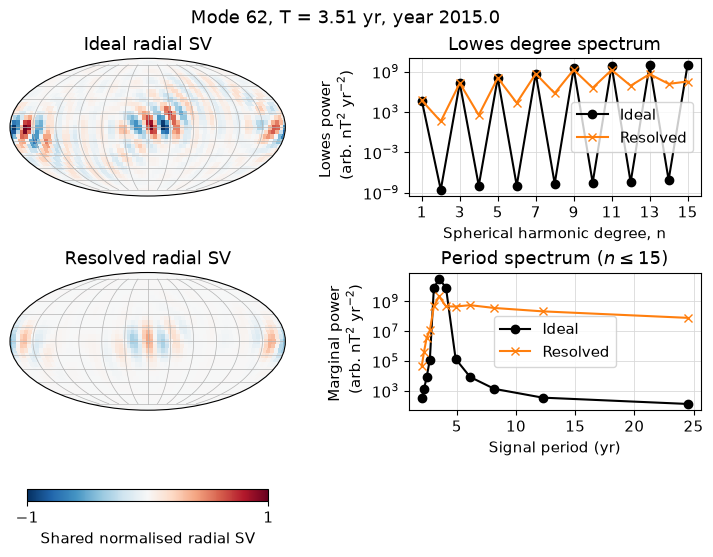

In [12]:
# Snapshot fields and spectra before and after CHAOS resolution
A_r = Truncate_Gauss_Coeffs(A_15_r, nmax)
ideal_field = (A_r @ gnm_ideal[demo_time]).reshape(state_shape)
resolved_field = (A_r @ gnm_resolved[demo_time]).reshape(state_shape)
shared_limit = np.max(np.abs([ideal_field, resolved_field]))
normalised_fields = [ideal_field / shared_limit, resolved_field / shared_limit]

degrees = np.arange(1, nmax + 1)
ideal_lowes = Instantaneous_Lowes_Spectrum(
    gnm_ideal[demo_time], a=r_earth, r=r_cmb
)
resolved_lowes = Instantaneous_Lowes_Spectrum(
    gnm_resolved[demo_time], a=r_earth, r=r_cmb
)
ideal_power, frequencies = Lowes_Degree_PSD_All_Degrees(
    gnm_ideal, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax
)
resolved_power, _ = Lowes_Degree_PSD_All_Degrees(
    gnm_resolved, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax
)
positive_f = (frequencies > 0) & (frequencies < 1 / 2)
periods = 1 / frequencies[positive_f]

plot_longitude = (longitude + 180) % 360 - 180
longitude_order = np.argsort(plot_longitude)
longitude_cyclic = np.append(plot_longitude[longitude_order], 180)

fig = plt.figure(
    figsize=(text_width, 0.75 * text_width), constrained_layout=True
)
grid = fig.add_gridspec(2, 2, width_ratios=[1.1, 1])
map_axes = [
    fig.add_subplot(grid[0, 0], projection="mollweide"),
    fig.add_subplot(grid[1, 0], projection="mollweide"),
]
spectrum_axes = [fig.add_subplot(grid[0, 1]), fig.add_subplot(grid[1, 1])]

for ax, field, title in zip(
    map_axes, normalised_fields, ["Ideal", "Resolved"]
):
    field_sorted = field[:, longitude_order]
    field_cyclic = np.column_stack((field_sorted, field_sorted[:, 0]))
    map_plot = ax.pcolormesh(
        np.deg2rad(longitude_cyclic), np.deg2rad(latitude), field_cyclic,
        cmap="RdBu_r", vmin=-1, vmax=1, shading="auto",
    )
    ax.set_title(f"{title} radial SV")
    ax.grid(True, color="0.7", linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

cbar = fig.colorbar(
    map_plot, ax=map_axes, orientation="horizontal", pad=0.08, shrink=0.75,
    label="Shared normalised radial SV",
)
cbar.set_ticks([-1, 1])

spectrum_axes[0].semilogy(
    degrees, ideal_lowes, "o-", color="black", label="Ideal"
)
spectrum_axes[0].semilogy(
    degrees, resolved_lowes, "x-", color="tab:orange", label="Resolved"
)
spectrum_axes[0].set(
    xlabel="Spherical harmonic degree, n",
    ylabel=rf"Lowes power "+"\n" + " (arb. nT$^2$ yr$^{-2}$)",
    title="Lowes degree spectrum", xticks=np.arange(1, nmax + 1, 2),
)

spectrum_axes[1].semilogy(
    periods, np.sum(ideal_power, axis=0)[positive_f],
    "o-", color="black", label="Ideal",
)
spectrum_axes[1].semilogy(
    periods, np.sum(resolved_power, axis=0)[positive_f],
    "x-", color="tab:orange", label="Resolved",
)
spectrum_axes[1].set(
    xlabel="Signal period (yr)",
    ylabel=rf"Marginal power "+"\n" + " (arb. nT$^2$ yr$^{-2}$)",
    title=rf"Period spectrum ($n\leq {nmax}$)",
)

for ax in spectrum_axes:
    ax.grid(True, which="both", color="0.85", linewidth=0.6)
    ax.legend()

fig.suptitle(
    f"Mode {demo_mode}, T = {mode_period:.2f} yr, "
    f"year {times_used[demo_time]:.1f}"
)
plt.show()

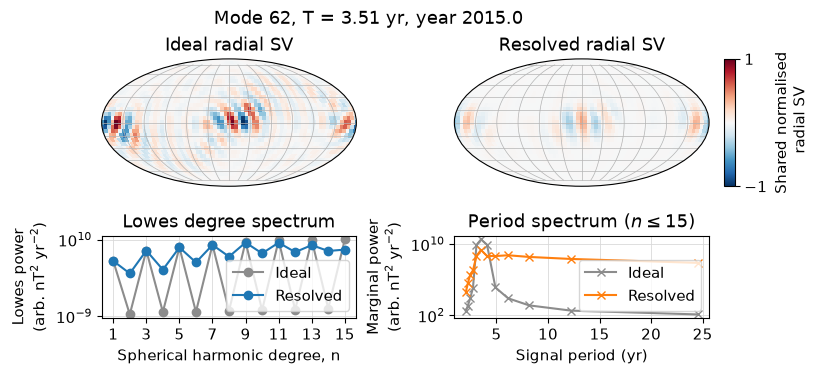

In [30]:
# Snapshot fields and spectra before and after CHAOS resolution
A_r = Truncate_Gauss_Coeffs(A_15_r, nmax)

ideal_field = (A_r @ gnm_ideal[demo_time]).reshape(state_shape)
resolved_field = (A_r @ gnm_resolved[demo_time]).reshape(state_shape)

shared_limit = np.max(np.abs([ideal_field, resolved_field]))
normalised_fields = [
    ideal_field / shared_limit,
    resolved_field / shared_limit,
]

degrees = np.arange(1, nmax + 1)

ideal_lowes = Instantaneous_Lowes_Spectrum(
    gnm_ideal[demo_time], a=r_earth, r=r_cmb
)
resolved_lowes = Instantaneous_Lowes_Spectrum(
    gnm_resolved[demo_time], a=r_earth, r=r_cmb
)

ideal_power, frequencies = Lowes_Degree_PSD_All_Degrees(
    gnm_ideal,
    a=r_earth,
    r=r_cmb,
    f_sample=f_sample,
    nmax=nmax,
)
resolved_power, _ = Lowes_Degree_PSD_All_Degrees(
    gnm_resolved,
    a=r_earth,
    r=r_cmb,
    f_sample=f_sample,
    nmax=nmax,
)

positive_f = (frequencies > 0) & (frequencies < 1 / 2)
periods = 1 / frequencies[positive_f]

plot_longitude = (longitude + 180) % 360 - 180
longitude_order = np.argsort(plot_longitude)
longitude_cyclic = np.append(plot_longitude[longitude_order], 180)

# Figure layout:
# top left: ideal snapshot
# top right: resolved snapshot
# bottom left: Lowes spectrum
# bottom right: period spectrum
fig = plt.figure(
    figsize=(text_width, 0.5 * text_width),
    constrained_layout=True,
)
grid = fig.add_gridspec(
    2,
    3,
    width_ratios=[1, 1, 0.055],
    height_ratios=[1, 0.5],
)

ideal_map_ax = fig.add_subplot(grid[0, 0], projection="mollweide")
resolved_map_ax = fig.add_subplot(grid[0, 1], projection="mollweide")

lowes_ax = fig.add_subplot(grid[1, 0])
period_ax = fig.add_subplot(grid[1, 1])

map_axes = [ideal_map_ax, resolved_map_ax]

for ax, field, title in zip(
    map_axes,
    normalised_fields,
    ["Ideal", "Resolved"],
):
    field_sorted = field[:, longitude_order]
    field_cyclic = np.column_stack(
        (field_sorted, field_sorted[:, 0])
    )

    map_plot = ax.pcolormesh(
        np.deg2rad(longitude_cyclic),
        np.deg2rad(latitude),
        field_cyclic,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        shading="auto",
    )

    ax.set_title(f"{title} radial SV")
    ax.grid(True, color="0.7", linewidth=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

colourbar_ax = inset_axes(
    resolved_map_ax,
    width="4%",
    height="100%",
    loc="lower left",
    bbox_to_anchor=(1.06, 0, 1, 1),
    bbox_transform=resolved_map_ax.transAxes,
    borderpad=0,
)

cbar = fig.colorbar(
    map_plot,
    cax=colourbar_ax,
    orientation="vertical",
    label="Shared normalised"+"\n"+" radial SV",
)
cbar.set_ticks([-1, 1])

# Instantaneous Lowes degree spectrum
lowes_ax.semilogy(
    degrees,
    ideal_lowes,
    color="0.55",
    marker="o",
    markerfacecolor="0.55",
    markeredgecolor="0.55",
    linestyle="-",
    label="Ideal",
)
lowes_ax.semilogy(
    degrees,
    resolved_lowes,
    color="tab:blue",
    marker="o",
    markerfacecolor="tab:blue",
    markeredgecolor="tab:blue",
    linestyle="-",
    label="Resolved",
)
lowes_ax.set(
    xlabel="Spherical harmonic degree, n",
    ylabel="Lowes power\n(arb. nT$^2$ yr$^{-2}$)",
    title="Lowes degree spectrum",
    xticks=np.arange(1, nmax + 1, 2),
)

# Period spectrum
period_ax.semilogy(
    periods,
    np.sum(ideal_power, axis=0)[positive_f],
    color="0.55",
    marker="x",
    linestyle="-",
    label="Ideal",
)
period_ax.semilogy(
    periods,
    np.sum(resolved_power, axis=0)[positive_f],
    color="tab:orange",
    marker="x",
    linestyle="-",
    label="Resolved",
)
period_ax.set(
    xlabel="Signal period (yr)",
    ylabel="Marginal power\n(arb. nT$^2$ yr$^{-2}$)",
    title=rf"Period spectrum ($n\leq {nmax}$)",
)

for ax in [lowes_ax, period_ax]:
    ax.grid(True, which="both", color="0.85", linewidth=0.6)
    ax.legend(loc="lower right")

fig.suptitle(
    f"Mode {demo_mode}, T = {mode_period:.2f} yr, "
    f"year {times_used[demo_time]:.1f}"
)
plt.savefig(f"{RESULT_DIR}/4_resolution_example.pdf", bbox_inches="tight")

plt.show()

In [25]:
# Unscaled ideal and resolved records for every synthetic wave
mode_numbers = np.arange(1, 63)
mode_numbers = [str(num) for num in mode_numbers]
_, _, all_mode_info = Synthetic_Full_SV_Record_Obtain(
    mode_numbers, times=times_evaluate_ideal_phasors, scale_flag=False, nmax=15
)
true_periods = np.array([
    all_mode_info[mode]["true_period"] for mode in mode_numbers
])
ideal_records = np.stack([
    all_mode_info[mode]["gnm_ideal"] for mode in mode_numbers
])
resolved_records = np.stack([
    all_mode_info[mode]["gnm_resolved"] for mode in mode_numbers
])

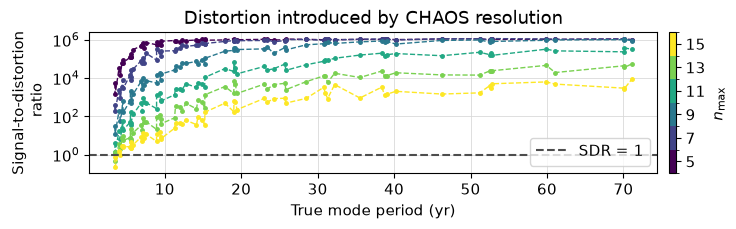

In [49]:
# SDR after projecting each resolved record onto its ideal record in radial SV space
n_modes, n_times, _ = ideal_records.shape
ideal_fields = np.zeros((n_modes, n_times, n_points_globally))
resolved_fields = np.zeros_like(ideal_fields)
area_weights = W2D.ravel()[None, None, :]
sdr = np.empty((15, n_modes))

from matplotlib.colors import BoundaryNorm

degrees_to_plot = [5, 7, 9, 11, 13, 15]

# One discrete colour per plotted degree
degree_colours = plt.colormaps["viridis"].resampled(len(degrees_to_plot))

# Boundaries halfway between your degree values
degree_bounds = [4, 6, 8, 10, 12, 14, 16]
degree_norm = BoundaryNorm(degree_bounds, degree_colours.N)

for degree in range(1, max(degrees_to_plot) + 1):
    degree_slice = Gauss_Degree_Slice(degree)
    A_degree = A_15_r[:, degree_slice]
    ideal_fields += (
        A_degree @ ideal_records[:, :, degree_slice].reshape(-1, 2 * degree + 1).T
    ).T.reshape(n_modes, n_times, n_points_globally)
    resolved_fields += (
        A_degree @ resolved_records[:, :, degree_slice].reshape(-1, 2 * degree + 1).T
    ).T.reshape(n_modes, n_times, n_points_globally)

    if degree in degrees_to_plot:
        ideal_power = np.sum(area_weights * ideal_fields**2, axis=(1, 2))
        resolved_power = np.sum(area_weights * resolved_fields**2, axis=(1, 2))
        cross_power = np.sum(
            area_weights * ideal_fields * resolved_fields, axis=(1, 2)
        )
        projection_scale = cross_power / ideal_power
        signal_power = projection_scale**2 * ideal_power
        distortion_power = (
            resolved_power - 2 * projection_scale * cross_power
            + projection_scale**2 * ideal_power
        )
        sdr[degree - 1] = signal_power / distortion_power

period_order = np.argsort(true_periods)

fig, ax = plt.subplots(
    figsize=(text_width, 0.3 * text_width), constrained_layout=True
)
for degree in degrees_to_plot:
    ax.semilogy(
        true_periods[period_order], sdr[degree - 1, period_order],
        color=degree_colours(degree_norm(degree)), linewidth=1, linestyle='--',
        marker="o", markersize=2.5,
    )

ax.axhline(1, color="0.3", linestyle="--", label="SDR = 1")
ax.set(
    xlabel="True mode period (yr)", ylabel="Signal-to-distortion"+"\n"+" ratio",
    title="Distortion introduced by CHAOS resolution",
)
ax.grid(True, which="both", color="0.85", linewidth=0.6)
ax.legend(loc="lower right")

degree_scale = plt.cm.ScalarMappable(
    norm=degree_norm,
    cmap=degree_colours,
)

degree_cbar = fig.colorbar(
    degree_scale,
    ax=ax,
    pad=0.02,
    ticks=degrees_to_plot,
    label=r"$n_{\max}$",
)

degree_cbar.set_ticklabels(degrees_to_plot)
plt.savefig(f"{RESULT_DIR}/4_sdr_resolution.pdf", bbox_inches="tight")


plt.show()

In [33]:
# Degree-period spectra for the unscaled mode, scaled mode, and CHAOS
_, resolved_unscaled, _ = Synthetic_Full_SV_Record_Obtain(
    [demo_mode], times=times_evaluate_ideal_phasors, scale_flag=False, nmax=15
)
amplitude_scaler = mode_amp_scalings[str(demo_mode)]
resolved_scaled = amplitude_scaler * resolved_unscaled
gnm_chaos = CHAOS_Full_SV_Record_Obtain(nmax=15)

resolved_spectrum, spectrum_f = Lowes_Degree_PSD_All_Degrees(
    resolved_unscaled, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=15
)
scaled_spectrum, _ = Lowes_Degree_PSD_All_Degrees(
    resolved_scaled, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=15
)
chaos_spectrum, _ = Lowes_Degree_PSD_All_Degrees(
    gnm_chaos, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=15
)

reliable_f = spectrum_f < 0.5
spectrum_f = spectrum_f[reliable_f]
spectra = [
    resolved_spectrum[:, reliable_f],
    scaled_spectrum[:, reliable_f],
    chaos_spectrum[:, reliable_f],
]

# The limiting water-level bin has the largest scaled-mode/CHAOS ratio
contact_degree, contact_bin = np.unravel_index(
    np.argmax(spectra[1] / spectra[2]), spectra[1].shape
)
print(
    f"Scaling contact: n={contact_degree + 1}, "
    f"period={1 / spectrum_f[contact_bin]:.2f} yr"
)

Scaling contact: n=9, period=3.50 yr


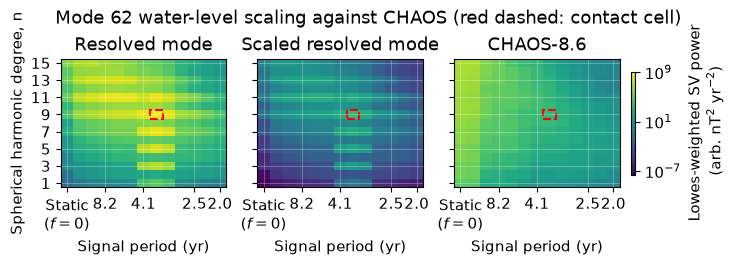

In [39]:
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

positive_power = np.concatenate([power[power > 0] for power in spectra])
power_norm = LogNorm(vmin=positive_power.min(), vmax=positive_power.max())
frequency_edges = np.arange(len(spectrum_f) + 1)
degree_edges = np.arange(0.5, 16.5, 1)
tick_bins = np.array([0, 3, 6, 10, len(spectrum_f) - 1])
tick_labels = [
    "Static\n($f=0$)" if index == 0 else f"{1 / spectrum_f[index]:.1f}"
    for index in tick_bins
]

fig, axes = plt.subplots(
    1, 3, figsize=(text_width, 0.35 * text_width),
    sharex=True, sharey=True, constrained_layout=True,
)
titles = ["Resolved mode", "Scaled resolved mode", "CHAOS-8.6"]

for index, (ax, power, title) in enumerate(zip(axes, spectra, titles)):
    spectrum_plot = ax.pcolormesh(
        frequency_edges, degree_edges, power, cmap="viridis",
        norm=power_norm, shading="flat",
    )
    contact = Rectangle(
        (contact_bin, contact_degree + 0.5), 1, 1, fill=False,
        edgecolor="red", linewidth=1.5, linestyle="--",
    )
    ax.add_patch(contact)
    ax.set(
        title=title, xlabel="Signal period (yr)",
        xticks=tick_bins + 0.5, xticklabels=tick_labels,
        yticks=np.arange(1, 16, 2),
    )
    ax.grid(True, color="white", linewidth=0.4, alpha=0.5)

axes[0].set_ylabel("Spherical harmonic degree, n")
fig.suptitle(
    f"Mode {demo_mode} water-level scaling against CHAOS "
    "(red dashed: contact cell)"
)
fig.colorbar(
    spectrum_plot,
    ax=axes[-1],
    orientation="vertical",
    pad=0.03,
    shrink=0.8,
    aspect=25,
    label=r"Lowes-weighted SV power"+"\n"+" (arb. nT$^2$ yr$^{-2}$)",
)

plt.savefig(f"{RESULT_DIR}/4_scaled_individual_mode.pdf", bbox_inches="tight")


plt.show()

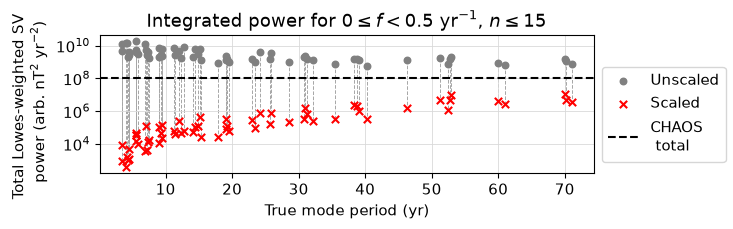

In [45]:
# Integrated reliable-band power before and after water-level scaling
unscaled_mode_power = []
for record in resolved_records:
    mode_power, mode_f = Lowes_Degree_PSD_All_Degrees(
        record, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=15
    )
    unscaled_mode_power.append(np.sum(mode_power[:, mode_f < 0.5]))

unscaled_mode_power = np.asarray(unscaled_mode_power)
amplitude_scalers = np.array([
    mode_amp_scalings[str(mode)] for mode in mode_numbers
])
scaled_mode_power = amplitude_scalers**2 * unscaled_mode_power
chaos_total_power = np.sum(spectra[2])

fig, ax = plt.subplots(
    figsize=(text_width, 0.3 * text_width), constrained_layout=True
)
for period, unscaled, scaled in zip(
    true_periods, unscaled_mode_power, scaled_mode_power
):
    ax.plot(
        [period, period], [unscaled, scaled], "--",
        color="0.65", linewidth=0.7, zorder=1,
    )

ax.scatter(
    true_periods, unscaled_mode_power, color="0.5", s=22,
    label="Unscaled", zorder=2,
)
ax.scatter(
    true_periods, scaled_mode_power, color="red", marker="x", s=28,
    label="Scaled", zorder=3,
)
ax.axhline(
    chaos_total_power, color="black", linestyle="--",
    label="CHAOS "+"\n"+" total",
)
ax.set(
    yscale="log", xlabel="True mode period (yr)",
    ylabel=r"Total Lowes-weighted SV "+"\n"+" power (arb. nT$^2$ yr$^{-2}$)",
    title=r"Integrated power for $0 \leq f < 0.5$ yr$^{-1}$, $n \leq 15$",
)
ax.grid(True, which="both", color="0.85", linewidth=0.6)
fig.legend(loc="outside right center")

plt.savefig(f"{RESULT_DIR}/4_all_modes_power_scaled.pdf", bbox_inches="tight")


plt.show()